In [4]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Importando datasets utilizados no projeto.

df_channels = pd.read_csv('/content/drive/MyDrive/portfolio_food&good_py/channels.csv')
df_deliveries = pd.read_csv('/content/drive/MyDrive/portfolio_food&good_py/deliveries.csv')
df_drivers = pd.read_csv('/content/drive/MyDrive/portfolio_food&good_py/drivers.csv')
df_orders = pd.read_csv('/content/drive/MyDrive/portfolio_food&good_py/orders.csv')
df_payments = pd.read_csv('/content/drive/MyDrive/portfolio_food&good_py/payments.csv')

# Alterando o encoding dos próximos dois datasets em decorrência dos acentos que aparecem nos arquivos.

caminhohub = '/content/drive/MyDrive/portfolio_food&good_py/hubs.csv'

df_hubs = pd.read_csv(caminhohub, encoding='latin-1')

caminhostores = '/content/drive/MyDrive/portfolio_food&good_py/stores.csv'
df_stores = pd.read_csv(caminhostores, encoding='latin-1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Descrição dos datasets:

Channels: Este dataset possui informações sobre os canais de venda (marketplaces) onde são vendidos os good e food de nossos lojistas.

Deliveries: Este dataset possui informações sobre as entregas realizadas por nossos entregadores parceiros.

Drivers: Este dataset possui informações sobre os entregadores parceiros. Eles ficam em nossos hubs e toda vez que um pedido é processado, são eles fazem as entregas na casa dos consumidores.

Hubs: Este dataset possui informações sobre os hubs do Delivery Center. Entenda que os Hubs são os centros de distribuição dos pedidos e é dali que saem as entregas.

Orders: Este dataset possui informações sobre as vendas processadas através da plataforma do Delivery Center.

Payments: Este dataset possui informações sobre os pagamentos realizados ao Delivery Center.

Stores: Este dataset possui informações sobre os lojistas. Eles utilizam a Plataforma do Delivery Center para vender seus itens (good e/ou food) nos marketplaces.


##Questão 1:
Numa ação de marketing, para atrair mais entregadores, vamos dar uma bonificação para os 20 entregadores que possuem maior distância percorrida ao todo. A bonificação vai variar de acordo com o tipo de profissional que ele é e o modelo que ele usa para se locomover (moto, bike, etc). Levante essas informações.

In [5]:
df_deliveries.head()

,delivery_id,delivery_order_id,driver_id,delivery_distance_meters,delivery_status
0,2174658,68413340,8378.0,5199.0,DELIVERED
1,2174660,68414309,2473.0,410.0,DELIVERED
2,2174661,68416230,7615.0,3784.0,DELIVERED
3,2174663,68412721,8378.0,5714.0,DELIVERED
4,2174675,68414018,10463.0,3746.0,DELIVERED


In [6]:
df_drivers.head()

,driver_id,driver_modal,driver_type
0,133,MOTOBOY,LOGISTIC OPERATOR
1,138,MOTOBOY,FREELANCE
2,140,MOTOBOY,FREELANCE
3,143,BIKER,FREELANCE
4,148,MOTOBOY,FREELANCE


In [7]:
# Unificando DF's de deliveries e drivers pela chave primária de ID do motorista.

df_questao_1 = pd.merge(df_deliveries, df_drivers, on='driver_id', how='inner')

df_questao_1.head()

,delivery_id,delivery_order_id,driver_id,delivery_distance_meters,delivery_status,driver_modal,driver_type
0,2174658,68413340,8378.0,5199.0,DELIVERED,MOTOBOY,FREELANCE
1,2174660,68414309,2473.0,410.0,DELIVERED,BIKER,FREELANCE
2,2174661,68416230,7615.0,3784.0,DELIVERED,MOTOBOY,LOGISTIC OPERATOR
3,2174663,68412721,8378.0,5714.0,DELIVERED,MOTOBOY,FREELANCE
4,2174675,68414018,10463.0,3746.0,DELIVERED,MOTOBOY,LOGISTIC OPERATOR


In [8]:
# Somando a distância por motorista, modelo de veículo e tipo.

dist_por_combo = (df_questao_1
                  .groupby(['driver_id','driver_modal','driver_type'], as_index=False)
                  .agg(dist_m=('delivery_distance_meters', 'sum')))

In [9]:
# Pega, para cada motorista (driver_id), o índice da linha com MAIOR distância percorrida.

max_combo = dist_por_combo.groupby('driver_id')['dist_m'].idxmax()

# Buscando os atríbutos (modelo de veículo e tipo) "campeões" por motorista.

campeao_combo = dist_por_combo.loc[max_combo,
                                  ['driver_id','driver_modal','driver_type','dist_m']]

campeao_combo = campeao_combo.rename(columns={'dist_m': 'dist_m_combo_campea'})

In [10]:
# Calculando a distância total por motorista

totais_por_motorista = (df_questao_1.groupby('driver_id', as_index=False)['delivery_distance_meters'].sum())

# Filtrando o top 20

top20 = (totais_por_motorista
         .sort_values('delivery_distance_meters', ascending=False)
         .head(20))

In [11]:
# Acrescentando as informações solicitadas de tipo de veículo e de profissional.

top20 = top20.merge(campeao_combo[['driver_id','driver_modal','driver_type']],
                    on='driver_id', how='left')

In [12]:
# Resultado final da questão 1:

print(top20)

    driver_id  delivery_distance_meters driver_modal        driver_type
0     26223.0                60504610.0      MOTOBOY  LOGISTIC OPERATOR
1     25651.0                32466086.0      MOTOBOY  LOGISTIC OPERATOR
2     15898.0                 8209339.0      MOTOBOY  LOGISTIC OPERATOR
3     17749.0                 8060048.0      MOTOBOY          FREELANCE
4       731.0                 7199476.0      MOTOBOY          FREELANCE
5     31023.0                 6096369.0      MOTOBOY          FREELANCE
6     42146.0                 4845699.0      MOTOBOY          FREELANCE
7     11063.0                 4829062.0      MOTOBOY          FREELANCE
8     14136.0                 4320123.0      MOTOBOY          FREELANCE
9       464.0                 4247737.0      MOTOBOY  LOGISTIC OPERATOR
10     7451.0                 3553855.0      MOTOBOY          FREELANCE
11     7754.0                 3407461.0      MOTOBOY          FREELANCE
12     7615.0                 3280119.0      MOTOBOY  LOGISTIC O

##Plus:
Acrescentando bonificação aos top 20 motoristas do nosso dataset:

In [13]:
# Criando uma tabela com os valores de bonificação a serem atribuídos.

bonus_tabela = pd.DataFrame({
    'driver_type':  ['LOGISTIC OPERATOR','FREELANCE'],
    'driver_modal': ['MOTOBOY','MOTOBOY',],
    'bonus_fixo':   [500, 400],
    'bonus_por_km': [0.5, 0.4]
})

In [14]:
# Criando merge entre a tabela de bonus e o top 20

top20_bonificacao = top20.merge(
    bonus_tabela,
    on=['driver_type', 'driver_modal'],
    how='left'
)

In [15]:
# Calculando bônus final (Bônus = fixo + (variável por km × distância total em km)

top20_bonificacao['bonus_final'] = (
    top20_bonificacao['bonus_fixo'].fillna(0)
    + top20_bonificacao['bonus_por_km'].fillna(0) * (top20_bonificacao['delivery_distance_meters'] / 1000.0)
)

In [16]:
#Ordenando resultado final em ordem decrescente de bônus final

resultado = top20_bonificacao.sort_values(
    'delivery_distance_meters', ascending=False
)[[
    'driver_id', 'driver_type', 'driver_modal',
    'delivery_distance_meters', 'bonus_final'
]]

resultado.head(20)

,driver_id,driver_type,driver_modal,delivery_distance_meters,bonus_final
0,26223.0,LOGISTIC OPERATOR,MOTOBOY,60504610.0,30752.3050
1,25651.0,LOGISTIC OPERATOR,MOTOBOY,32466086.0,16733.0430
2,15898.0,LOGISTIC OPERATOR,MOTOBOY,8209339.0,4604.6695
3,17749.0,FREELANCE,MOTOBOY,8060048.0,3624.0192
4,731.0,FREELANCE,MOTOBOY,7199476.0,3279.7904
5,31023.0,FREELANCE,MOTOBOY,6096369.0,2838.5476
6,42146.0,FREELANCE,MOTOBOY,4845699.0,2338.2796
7,11063.0,FREELANCE,MOTOBOY,4829062.0,2331.6248
8,14136.0,FREELANCE,MOTOBOY,4320123.0,2128.0492
9,464.0,LOGISTIC OPERATOR,MOTOBOY,4247737.0,2623.8685


##Questão 2:

Como se comporta a distância média das entregas por tipo de motorista e modal (moto, bike etc.)?

In [17]:
# Criando merge entre deliveries e drivers

df_questao_2 = df_deliveries.merge(
    df_drivers[['driver_id','driver_type','driver_modal']],
    on='driver_id', how='left'
)

# Removendo linhas com dados vazios

df_questao_2 = df_questao_2.dropna(subset=['delivery_distance_meters', 'driver_modal', 'driver_type'])

In [18]:
# Calculando distância média por entrega (em metros)

media_metros = (
    df_questao_2.groupby(['driver_type','driver_modal'], as_index=False)['delivery_distance_meters']
      .mean().reset_index(drop=True)
)

In [19]:
# Criando coluna com média em KM
media_metros['distancia_media_km'] = media_metros['delivery_distance_meters'] / 1000

# Ordenando coluna pela maior distância média
media_metros = media_metros.sort_values('distancia_media_km', ascending=False)

media_metros

,driver_type,driver_modal,delivery_distance_meters,distancia_media_km
3,LOGISTIC OPERATOR,MOTOBOY,3864.436028,3.864436
1,FREELANCE,MOTOBOY,3180.162845,3.180163
2,LOGISTIC OPERATOR,BIKER,2326.571429,2.326571
0,FREELANCE,BIKER,1109.019529,1.109020


##PLUS:
Apresentando a media_metros em um gráfico interativo usando a biblioteca Plotly

In [28]:
import plotly.express as px

# Copiando o dataframe final da questão 2
media_plot = media_metros.copy()

# Criando uma coluna unificando tipo + modal para facilitar a visualização
media_plot['grupo'] = (
    media_plot['driver_type'].astype(str)
    + " - "
    + media_plot['driver_modal'].astype(str))

# Criando gráfico de barras horizontal

fig = px.bar(
    media_plot,
    x='distancia_media_km',       # eixo X: distância média
    y='grupo',                    # eixo Y: tipo-modal
    color='driver_type',          # cor representando o tipo de motorista
    orientation='h',              # barras horizontais
    title='Distância média por tipo de motorista e modal',
    labels={
        'distancia_media_km': 'Distância média (km)',
        'grupo': 'Tipo - Modal',
        'driver_type': 'Tipo de motorista'})

# Exibindo o valor ao lado da barra

fig.update_traces(
    text=media_plot['distancia_media_km'].round(2).astype(str) + ' km',
    textposition='outside')

# Ajustando layout visual

fig.update_layout(
    template='simple_white',
    bargap=0.25,)

fig.show()

##Questão 3:

Como está distribuído o volume de pedidos por estado e por categoria (Food vs Goods)?

In [ ]:
# Criando merge entre os datasets orders, stores, e hubs

df_questao_3 = (
    df_orders
    .merge(df_stores[['store_id','store_segment','hub_id']], on='store_id', how='left')
    .merge(df_hubs[['hub_id','hub_state']], on='hub_id', how='left')
)

In [ ]:
# Contando pedidos por estado e segmento utilizando o pivot table

tabela_questao_3 = pd.pivot_table(
    df_questao_3,
    index='hub_state',
    columns='store_segment',
    values='order_id',
    aggfunc='count',     # Conta quantos pedidos
    fill_value=0         # Substitui NaN por 0
)

In [ ]:
# Ordenando por total de pedidos (soma das colunas)

tabela_questao_3['TOTAL'] = tabela_questao_3.sum(axis=1)
tabela_questao_3 = tabela_questao_3.sort_values('TOTAL', ascending=False)

tabela_questao_3

store_segment,FOOD,GOOD,TOTAL
hub_state,,,
SP,136530,31060,167590
RJ,127161,10433,137594
RS,32000,2429,34429
PR,26084,3302,29386


#PLUS:
Criando gráfico para melhor visualização dos dados utilizando a biblioteca matplotlyb

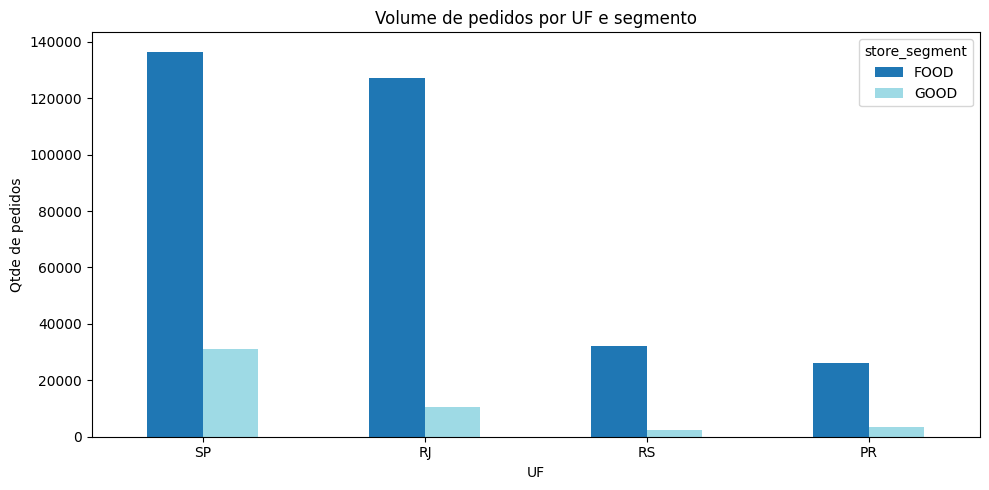

In [ ]:
# Importando biblioteca para gerar gráficos

import matplotlib.pyplot as plt

# Removendo coluna de total, pois o gráfico já vai somar por categoria

tabela_questao_3_plot = tabela_questao_3.drop(columns=['TOTAL'])

# Criando gráfico de barras empilhadas por UF
ax = tabela_questao_3_plot.plot(
    kind='bar', # Tipo de gráfico (barras)
    figsize=(10, 5), # Tamanho do gráfico
    colormap='tab20' # Paleta de cores
)

ax.set_title('Volume de pedidos por UF e segmento') # Titulo do gráfico
ax.set_xlabel('UF') # Titulo eixo X
ax.set_ylabel('Qtde de pedidos') # Titulo eixo Y
plt.xticks(rotation=0)        # UF na horizontal
plt.tight_layout()
plt.show()